In [1]:
import sys
from pathlib import Path

project_root = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'exp').exists()), None)
if project_root is None:
    raise RuntimeError("Could not find project root containing 'exp'.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
from exp.define_system import define_system
from exp.train_test import train_test

import matplotlib.pyplot as plt


def compute_coordinate_r2(true_states, predicted_states):
    residual_ss = np.sum((true_states - predicted_states) ** 2, axis=0)
    centered_true_states = true_states - true_states.mean(axis=0, keepdims=True)
    total_ss = np.sum(centered_true_states ** 2, axis=0)

    coordinate_r2 = np.full(true_states.shape[1], np.nan)
    valid = total_ss > 0
    coordinate_r2[valid] = 1.0 - residual_ss[valid] / total_ss[valid]
    return coordinate_r2

In [2]:
n, p, m = 4, 2, 3
rho_target=1.0
sys_seed = 0

A, B, C = define_system(n, p, m, rho_target, seed=sys_seed)
W = 0.05 * np.eye(n)
V = 0.1 * np.eye(m)

Spectral radius of A:  1.0000000000000007
Observable? True (rank 4 of 4)
Controllable? True (rank 4 of 4)


In [3]:
model, kf_states, act_states, _ = train_test(
    A=A,
    B=B,
    C=C,
    W=W,
    V=V,
    L=10,
    H=1,
    T=10000,
    testT=1000,
    epochs=150,
    batch_size=64,
    lr=0.05,
    step_size=2,
    gamma=0.9,
    weight_decay=1e-3,
    train_seed=10,
    torch_seed=20,
    test_seed=30
)

Epoch [1/150], Training Loss: 526.3600, Learning Rate: 0.050000
Epoch [2/150], Training Loss: 3.2082, Learning Rate: 0.050000
Epoch [3/150], Training Loss: 3.6809, Learning Rate: 0.045000
Epoch [4/150], Training Loss: 4.0325, Learning Rate: 0.045000
Epoch [5/150], Training Loss: 2.0961, Learning Rate: 0.040500
Epoch [6/150], Training Loss: 3.4363, Learning Rate: 0.040500
Epoch [7/150], Training Loss: 2.0993, Learning Rate: 0.036450
Epoch [8/150], Training Loss: 2.1097, Learning Rate: 0.036450
Epoch [9/150], Training Loss: 2.5991, Learning Rate: 0.032805
Epoch [10/150], Training Loss: 1.3670, Learning Rate: 0.032805
Epoch [11/150], Training Loss: 1.9744, Learning Rate: 0.029525
Epoch [12/150], Training Loss: 1.7866, Learning Rate: 0.029525
Epoch [13/150], Training Loss: 1.2073, Learning Rate: 0.026572
Epoch [14/150], Training Loss: 1.4998, Learning Rate: 0.026572
Epoch [15/150], Training Loss: 1.1197, Learning Rate: 0.023915
Epoch [16/150], Training Loss: 1.5953, Learning Rate: 0.023915

H=1 coordinate R^2: [0.9981 0.9982 0.9986 0.9991]


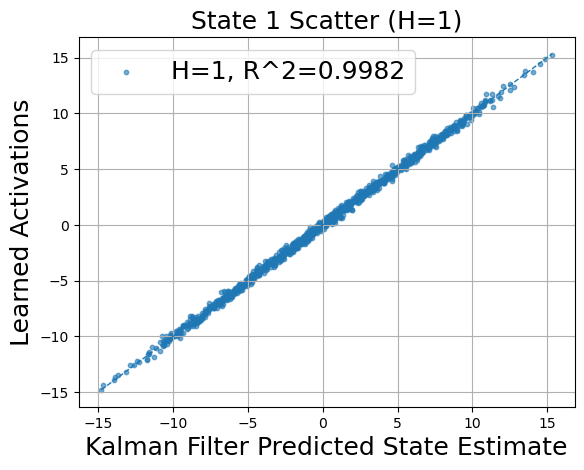

In [4]:
plot_state_index = 1
r2_h1 = compute_coordinate_r2(kf_states, act_states)
print(f'H=1 coordinate R^2: {np.round(r2_h1, 4)}')

x_kf = kf_states[:, plot_state_index]
x_act = act_states[:, plot_state_index]

plt.figure(figsize=(6.4, 4.8))

plt.scatter(x_kf, x_act, s=10, alpha=0.6, label=f'H=1, R^2={r2_h1[plot_state_index]:.4f}')

# Add y=x reference line
vmin = min(np.min(x_kf), np.min(x_act))
vmax = max(np.max(x_kf), np.max(x_act))
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", linewidth=1)
plt.grid(True)
plt.xlabel("Kalman Filter Predicted State Estimate", fontsize=18)
plt.ylabel("Learned Activations", fontsize=18)
plt.title(f'State {plot_state_index} Scatter (H=1)', fontsize=18)
plt.legend(fontsize=18)
plt.savefig('figs/scatter_plot_h1.png', dpi=600, bbox_inches="tight")
plt.show()

In [5]:
model, kf_states, act_states, _ = train_test(
    A=A,
    B=B,
    C=C,
    W=W,
    V=V,
    L=10,
    H=5,
    T=10000,
    testT=1000,
    epochs=150,
    batch_size=64,
    lr=0.05,
    step_size=2,
    gamma=0.9,
    weight_decay=1e-3,
    train_seed=10,
    torch_seed=20,
    test_seed=30
)

Epoch [1/150], Training Loss: 1861.4048, Learning Rate: 0.050000
Epoch [2/150], Training Loss: 16.8998, Learning Rate: 0.050000
Epoch [3/150], Training Loss: 15.3967, Learning Rate: 0.045000
Epoch [4/150], Training Loss: 15.2128, Learning Rate: 0.045000
Epoch [5/150], Training Loss: 15.1609, Learning Rate: 0.040500
Epoch [6/150], Training Loss: 16.4806, Learning Rate: 0.040500
Epoch [7/150], Training Loss: 13.2137, Learning Rate: 0.036450
Epoch [8/150], Training Loss: 13.6918, Learning Rate: 0.036450
Epoch [9/150], Training Loss: 12.2346, Learning Rate: 0.032805
Epoch [10/150], Training Loss: 12.0983, Learning Rate: 0.032805
Epoch [11/150], Training Loss: 11.2432, Learning Rate: 0.029525
Epoch [12/150], Training Loss: 11.5556, Learning Rate: 0.029525
Epoch [13/150], Training Loss: 11.0791, Learning Rate: 0.026572
Epoch [14/150], Training Loss: 10.9575, Learning Rate: 0.026572
Epoch [15/150], Training Loss: 10.7773, Learning Rate: 0.023915
Epoch [16/150], Training Loss: 10.1357, Learnin

H=5 coordinate R^2: [0.9959 0.9978 0.9997 0.9989]


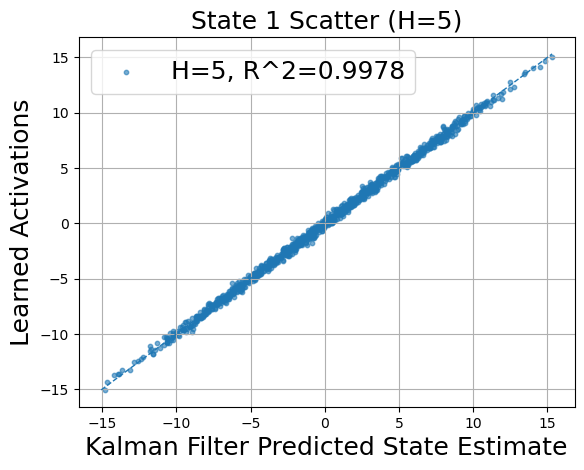

In [6]:
plot_state_index = 1
r2_h5 = compute_coordinate_r2(kf_states, act_states)
print(f'H=5 coordinate R^2: {np.round(r2_h5, 4)}')

x_kf = kf_states[:, plot_state_index]
x_act = act_states[:, plot_state_index]

plt.figure(figsize=(6.4, 4.8))

plt.scatter(x_kf, x_act, s=10, alpha=0.6, label=f'H=5, R^2={r2_h5[plot_state_index]:.4f}')

# Add y=x reference line
vmin = min(np.min(x_kf), np.min(x_act))
vmax = max(np.max(x_kf), np.max(x_act))
plt.plot([vmin, vmax], [vmin, vmax], linestyle="--", linewidth=1)
plt.grid(True)
plt.xlabel("Kalman Filter Predicted State Estimate", fontsize=18)
plt.ylabel("Learned Activations", fontsize=18)
plt.title(f'State {plot_state_index} Scatter (H=5)', fontsize=18)
plt.legend(fontsize=18)
plt.savefig('figs/scatter_plot_h5.png', dpi=600, bbox_inches="tight")
plt.show()

In [7]:
r2_summary = pd.DataFrame(
    [r2_h1, r2_h5],
    index=['H=1', 'H=5'],
    columns=[f'state_{i}_r2' for i in range(r2_h1.shape[0])],
)
r2_summary['mean_r2'] = r2_summary.mean(axis=1)
r2_summary.round(4)


,state_0_r2,state_1_r2,state_2_r2,state_3_r2,mean_r2
H=1,0.9981,0.9982,0.9986,0.9991,0.9985
H=5,0.9959,0.9978,0.9997,0.9989,0.9981
